Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda

Original CSV size:
2719

Original eye label distribution:
eye_label
complex    1687
simple     1032
Name: count, dtype: int64

FULL TRAINING DATASET

Training label distribution:
eye_label
complex    1687
simple     1031
Name: count, dtype: int64

Total training images: 2718

Training image list saved to:
/content/drive/MyDrive/eye_allimages_training_only.csv

Training images: 2718

Final classification layer:
Linear(in_features=512, out_features=1, bias=True)

Trainable parameters: 11,177,025
Total parameters: 11,177,025

START TRAINING

Epoch 001/100 | Loss: 0.659641 | Training Accuracy: 62.25%
Epoch 002/100 | Loss: 0.500685 | Training Accuracy: 75.31%
Epoch 003/100 | Loss: 0.307374 | Training Accuracy: 86.79%
Epoch 004/100 | Loss: 0.200275 | Training Accuracy: 92.46%
Epoch 005/100 | Loss: 0.118173 | Training Accuracy: 96.14%
Epoch 006/1

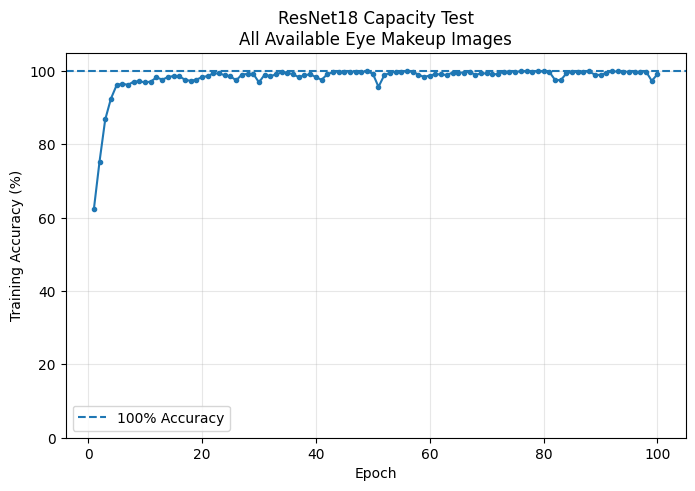

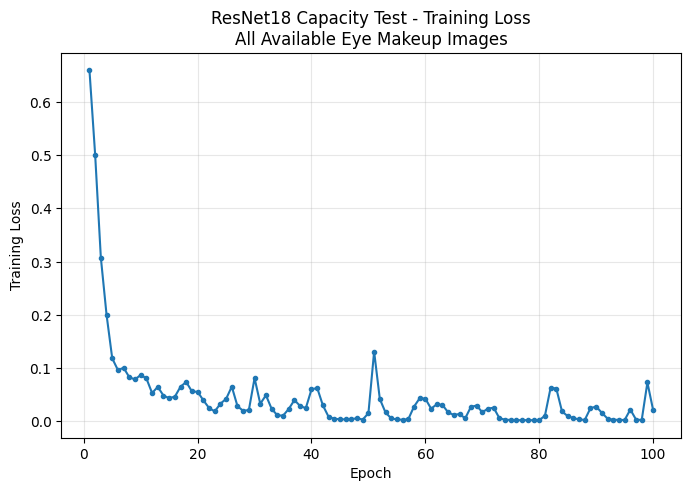


Prediction results saved to:
/content/drive/MyDrive/eye_allimages_overfit_predictions.csv

Number of misclassified training images: 3

Misclassified images:
                                               filename eye_label  \
637                                          vFG672.png    simple   
744   4298ad4c38d17597-5c06c575c1723922-e8ae039f36c7...   complex   
1661                                         vRX869.png   complex   

      predicted_label  complex_probability  
637                 1             0.999999  
744                 0             0.475440  
1661                0             0.469023  


In [2]:
# ============================================================
# ResNet18 Capacity Test
# All available Eye Makeup Images
# No Data Augmentation
# Goal: Test whether ResNet18 can reach 100% training accuracy
# ============================================================

import os
import random
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

import matplotlib.pyplot as plt

from google.colab import drive

drive.mount('/content/drive')


# ============================================================
# 3. RANDOM SEED
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ============================================================
# 4. DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)


# ============================================================
# 5. PATHS AND SETTINGS
# ============================================================

IMG_DIR = '/content/drive/MyDrive/makeup/eye'

CSV_PATH = '/content/complexity_labels_region_binary.csv'

SAVE_PATH = (
    '/content/drive/MyDrive/'
    'resnet18_eye_allimages_overfit.pth'
)

# Maximum number of epochs
EPOCHS = 100

LR = 1e-4

BATCH_SIZE = 16


# ============================================================
# 6. LABEL MAP
# ============================================================

# Binary classification: simple  = 0,complex = 1
LABEL_MAP = {
    'simple': 0.0,
    'complex': 1.0
}


# ============================================================
# 7. TRANSFORM
# ============================================================

# IMPORTANT:
# NO DATA AUGMENTATION for this experiment; Only resize + normalization

train_tf = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# ============================================================
# 8. DATASET CLASS
# ============================================================

class MakeupDataSet(Dataset):

    def __init__(self, df, img_dir, transform):

        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform


    def __len__(self):

        return len(self.df)


    def __getitem__(self, index):

        row = self.df.iloc[index]

        image_path = os.path.join(
            self.img_dir,
            row['filename']
        )

        image = Image.open(
            image_path
        ).convert('RGB')

        image = self.transform(image)

        label = torch.tensor(
            LABEL_MAP[row['eye_label']],
            dtype=torch.float32
        )

        return image, label


# ============================================================
# 9. LOAD CSV
# ============================================================

df = pd.read_csv(CSV_PATH)

print("\nOriginal CSV size:")
print(len(df))

print("\nOriginal eye label distribution:")
print(df['eye_label'].value_counts())


# ============================================================
# 10. KEEP ONLY SIMPLE AND COMPLEX
# ============================================================
# Use every available image that has a simple/complex eye label.
# No random sampling and no train/validation split.

df = df[
    df['eye_label'].isin(['simple', 'complex'])
].copy()


# ============================================================
# 11. KEEP ONLY IMAGES THAT EXIST IN THE FOLDER
# ============================================================

df["image_path"] = df["filename"].apply(
    lambda x: os.path.join(IMG_DIR, x)
)

df = df[
    df["image_path"].apply(os.path.exists)
].copy().reset_index(drop=True)


# ============================================================
# 12. USE ALL AVAILABLE IMAGES FOR TRAINING
# ============================================================

train_df = df.copy()

print("\n======================================")
print("FULL TRAINING DATASET")
print("======================================")

print("\nTraining label distribution:")
print(train_df['eye_label'].value_counts())

print("\nTotal training images:", len(train_df))


# ============================================================
# 13. SAVE TRAINING IMAGE LIST
# ============================================================

TRAIN_CSV_PATH = (
    '/content/drive/MyDrive/'
    'eye_allimages_training_only.csv'
)

train_df[
    ['filename', 'eye_label']
].to_csv(
    TRAIN_CSV_PATH,
    index=False
)

print("\nTraining image list saved to:")
print(TRAIN_CSV_PATH)


# ============================================================
# 19. CREATE TRAINING DATASET
# ============================================================

# All available images are used for training because the goal is to test whether ResNet18 can memorize the full dataset.

train_dataset = MakeupDataSet(
    train_df,
    IMG_DIR,
    train_tf
)


# ============================================================
# 20. CREATE TRAINING DATALOADER
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

print(
    "\nTraining images:",
    len(train_dataset)
)


# ============================================================
# 21. CREATE RESNET18
# ============================================================

model = models.resnet18(
    weights='IMAGENET1K_V1'
)


# ============================================================
# 22. REPLACE FINAL CLASSIFICATION LAYER
# ============================================================

# Binary classification:
# one output logit
#
# BCEWithLogitsLoss will apply sigmoid internally.

model.fc = nn.Linear(
    model.fc.in_features,
    1
)


# ============================================================
# 23. TRAIN THE ENTIRE RESNET18
# ============================================================

# DO NOT freeze the network for this experiment.
#
# We WANT the network to overfit / memorize all available images.

for param in model.parameters():

    param.requires_grad = True


model = model.to(device)


# ============================================================
# 24. LOSS FUNCTION
# ============================================================

criterion = nn.BCEWithLogitsLoss()


# ============================================================
# 25. OPTIMIZER
# ============================================================

# No weight decay.
# we are NOT trying to prevent overfitting.
# We are intentionally testing model capacity.

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR
)


# ============================================================
# 26. PRINT MODEL INFORMATION
# ============================================================

print("\nFinal classification layer:")

print(model.fc)


trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

print(
    "\nTrainable parameters:",
    f"{trainable_params:,}"
)

print(
    "Total parameters:",
    f"{total_params:,}"
)


# ============================================================
# 27. STORAGE FOR TRAINING CURVES
# ============================================================

train_losses = []
train_accuracies = []

# Used for early stopping after 100% accuracy
consecutive_100 = 0


# ============================================================
# 28. TRAINING LOOP
# ============================================================

print("\n======================================")
print("START TRAINING")
print("======================================\n")


for epoch in range(EPOCHS):

    model.train()

    running_loss = 0.0

    train_correct = 0
    train_total = 0


    # --------------------------------------------------------
    # TRAIN ONE EPOCH
    # --------------------------------------------------------

    for images, labels in train_loader:

        images = images.to(device)

        labels = labels.to(
            device
        ).unsqueeze(1)


        # Clear previous gradients
        optimizer.zero_grad()


        # Forward pass
        outputs = model(images)


        # Calculate loss
        loss = criterion(
            outputs,
            labels
        )


        # Backpropagation
        loss.backward()


        # Update model weights
        optimizer.step()


        # ----------------------------------------------------
        # ACCUMULATE LOSS
        # ----------------------------------------------------

        running_loss += (
            loss.item()
            * images.size(0)
        )


        # ----------------------------------------------------
        # PREDICTIONS
        # ----------------------------------------------------

        probabilities = torch.sigmoid(
            outputs
        )

        preds = (
            probabilities >= 0.5
        ).float()


        train_correct += (
            preds == labels
        ).sum().item()

        train_total += (
            labels.size(0)
        )


    # ========================================================
    # EPOCH STATISTICS
    # ========================================================

    train_loss = (
        running_loss
        / train_total
    )

    train_acc = (
        train_correct
        / train_total
    )


    train_losses.append(
        train_loss
    )

    train_accuracies.append(
        train_acc
    )


    print(
        f"Epoch "
        f"{epoch + 1:03d}/{EPOCHS} | "
        f"Loss: {train_loss:.6f} | "
        f"Training Accuracy: "
        f"{train_acc * 100:.2f}%"
    )


    # ========================================================
    # CHECK IF TRAINING ACCURACY REACHES 100%
    # ========================================================

    if train_acc == 1.0:

        consecutive_100 += 1

    else:

        consecutive_100 = 0


    # Require 3 consecutive epochs at 100%
    # so that one lucky epoch does not trigger stopping.

    if consecutive_100 >= 3:

        print(
            "\n======================================"
        )

        print(
            "Reached 100% training accuracy "
            "for 3 consecutive epochs."
        )

        print(
            "ResNet18 successfully memorized "
            "the full training dataset."
        )

        print(
            "======================================"
        )

        break


# ============================================================
# 29. SAVE MODEL
# ============================================================

torch.save(
    model.state_dict(),
    SAVE_PATH
)

print(
    "\nModel saved to:"
)

print(SAVE_PATH)


# ============================================================
# 30. FINAL TRAINING-SET EVALUATION
# ============================================================

# IMPORTANT:
#
# Now evaluate the SAME training images again using model.eval().
#
# This gives us the final training-set accuracy after training.

model.eval()

final_correct = 0
final_total = 0

all_predictions = []
all_labels = []
all_probabilities = []


with torch.no_grad():

    for images, labels in train_loader:

        images = images.to(device)

        labels = labels.to(
            device
        ).unsqueeze(1)


        outputs = model(images)


        probabilities = torch.sigmoid(
            outputs
        )


        preds = (
            probabilities >= 0.5
        ).float()


        final_correct += (
            preds == labels
        ).sum().item()

        final_total += (
            labels.size(0)
        )


        all_predictions.extend(
            preds.squeeze(1)
            .cpu()
            .numpy()
        )


        all_labels.extend(
            labels.squeeze(1)
            .cpu()
            .numpy()
        )


        all_probabilities.extend(
            probabilities.squeeze(1)
            .cpu()
            .numpy()
        )


# ============================================================
# 31. FINAL TRAINING ACCURACY
# ============================================================

final_train_acc = (
    final_correct
    / final_total
)


print(
    "\n======================================"
)

print(
    "FINAL RESULT"
)

print(
    "======================================"
)

print(
    f"Final Training Accuracy: "
    f"{final_train_acc * 100:.2f}%"
)

print(
    f"Correct predictions: "
    f"{final_correct}/{final_total}"
)


# ============================================================
# 32. INTERPRET RESULT
# ============================================================

if final_train_acc == 1.0:

    print(
        "\nSUCCESS:"
    )

    print(
        "ResNet18 achieved 100% training accuracy."
    )

    print(
        "This indicates that ResNet18 has enough "
        "capacity to memorize this full training dataset."
    )

else:

    print(
        "\nResNet18 did NOT reach 100% "
        "final training accuracy."
    )

    print(
        "Further investigation may be needed."
    )


# ============================================================
# 33. PLOT TRAINING ACCURACY
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    range(
        1,
        len(train_accuracies) + 1
    ),
    np.array(
        train_accuracies
    ) * 100,
    marker='o',
    markersize=3
)

plt.axhline(
    y=100,
    linestyle='--',
    label='100% Accuracy'
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Training Accuracy (%)"
)

plt.title(
    "ResNet18 Capacity Test\n"
    "All Available Eye Makeup Images"
)

plt.ylim(
    0,
    105
)

plt.grid(
    alpha=0.3
)

plt.legend()

plt.show()


# ============================================================
# 34. PLOT TRAINING LOSS
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    range(
        1,
        len(train_losses) + 1
    ),
    train_losses,
    marker='o',
    markersize=3
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Training Loss"
)

plt.title(
    "ResNet18 Capacity Test - Training Loss\n"
    "All Available Eye Makeup Images"
)

plt.grid(
    alpha=0.3
)

plt.show()


# ============================================================
# 35. SAVE PREDICTION RESULTS
# ============================================================

evaluation_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)


model.eval()

predictions = []
probabilities_list = []


with torch.no_grad():

    for images, labels in evaluation_loader:

        images = images.to(device)

        outputs = model(images)

        probabilities = torch.sigmoid(
            outputs
        )

        preds = (
            probabilities >= 0.5
        ).float()


        predictions.extend(
            preds.squeeze(1)
            .cpu()
            .numpy()
            .astype(int)
        )

        probabilities_list.extend(
            probabilities.squeeze(1)
            .cpu()
            .numpy()
        )


# Add prediction results to dataframe

result_df = train_df[
    ['filename', 'eye_label']
].copy()


result_df[
    'true_label'
] = result_df[
    'eye_label'
].map({
    'simple': 0,
    'complex': 1
})


result_df[
    'predicted_label'
] = predictions


result_df[
    'complex_probability'
] = probabilities_list


result_df[
    'correct'
] = (
    result_df['true_label']
    ==
    result_df['predicted_label']
)


# ============================================================
# 36. SAVE PREDICTIONS
# ============================================================

RESULT_CSV_PATH = (
    '/content/drive/MyDrive/'
    'eye_allimages_overfit_predictions.csv'
)

result_df.to_csv(
    RESULT_CSV_PATH,
    index=False
)

print(
    "\nPrediction results saved to:"
)

print(
    RESULT_CSV_PATH
)


# ============================================================
# 37. SHOW MISCLASSIFIED IMAGES
# ============================================================

wrong_df = result_df[
    result_df['correct'] == False
]

print(
    "\nNumber of misclassified training images:",
    len(wrong_df)
)


if len(wrong_df) > 0:

    print(
        "\nMisclassified images:"
    )

    print(
        wrong_df[
            [
                'filename',
                'eye_label',
                'predicted_label',
                'complex_probability'
            ]
        ]
    )

else:

    print(
        "\nNo misclassified images."
    )

    print(
        "All training images were "
        "classified correctly."
    )